# 🍄 Mushroom Proportions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

mushrooms = pd.read_csv("../../data/mushrooms.csv")
mushrooms.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,Poisonous,Convex,Smooth,Brown,Bruises,Pungent,Free,Close,Narrow,Black,...,Smooth,White,White,Partial,White,One,Pendant,Black,Scattered,Urban
1,Edible,Convex,Smooth,Yellow,Bruises,Almond,Free,Close,Broad,Black,...,Smooth,White,White,Partial,White,One,Pendant,Brown,Numerous,Grasses
2,Edible,Bell,Smooth,White,Bruises,Anise,Free,Close,Broad,Brown,...,Smooth,White,White,Partial,White,One,Pendant,Brown,Numerous,Meadows
3,Poisonous,Convex,Scaly,White,Bruises,Pungent,Free,Close,Narrow,Brown,...,Smooth,White,White,Partial,White,One,Pendant,Black,Scattered,Urban
4,Edible,Convex,Smooth,Green,No Bruises,NaN,Free,Crowded,Broad,Black,...,Smooth,White,White,Partial,White,One,Evanescent,Brown,Abundant,Grasses


Notice that all the data is **textual**. We will have to convert the data to use in a chart.
Right now most of the data is represented as an **strings**.

In [11]:
print(mushrooms.select_dtypes(["str"]).columns)

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='str')


Convert the "class" column, and the rest of the columns to a `category`:

In [12]:
cols = mushrooms.select_dtypes(["str"]).columns
mushrooms[cols] = mushrooms[cols].astype("category")

In [ ]:
# Groub py the "class" column. There are only two categories: Edible & Poisonous.
edibleclass = mushrooms.groupby(["class"]).count()
edibleclass

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
class,,,,,,,,,,,,,,,,,,,,,
Edible,4208,4208,4208,4208,800,4208,4208,4208,4208,4208,...,4208,4208,4208,4208,4208,4208,4208,4208,4208,4208
Poisonous,3916,3916,3916,3916,3796,3916,3916,3916,3916,3916,...,3916,3916,3916,3916,3916,3880,3880,3916,3916,3916


### Pie!

A pie chart showing the proportions of this data according to these two classes

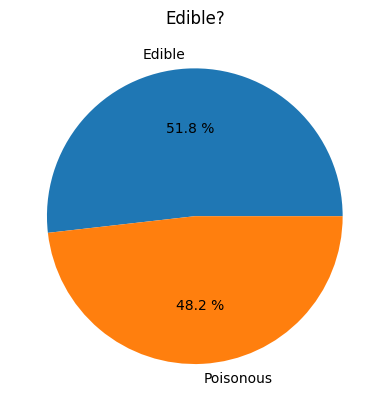

In [14]:
labels = ["Edible", "Poisonous"]
plt.pie(edibleclass["population"], labels=labels, autopct="%.1f %%")
plt.title("Edible?")

plt.show()

### Donuts - a pie chart with a hole in the middle!

Let's examine the various habitats where the mushrooms grow:

In [15]:
habitat = mushrooms.groupby(["habitat"]).count()
habitat

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population
habitat,,,,,,,,,,,,,,,,,,,,,
Grasses,2148,2148,2148,2148,2148,1056,2148,2148,2148,2148,...,2148,2148,2148,2148,2148,2148,2148,2148,2148,2148
Leaves,832,832,832,832,832,576,832,832,832,832,...,832,832,832,832,832,832,832,832,832,832
Meadows,292,292,292,292,292,256,292,292,292,292,...,292,292,292,292,292,292,292,292,292,292
Paths,1144,1144,1144,1144,1144,1104,1144,1144,1144,1144,...,1144,1144,1144,1144,1144,1144,1144,1144,1144,1144
Urban,368,368,368,368,368,272,368,368,368,368,...,368,368,368,368,368,368,368,368,368,368
Waste,192,192,192,192,192,0,192,192,192,192,...,192,192,192,192,192,192,192,192,192,192
Wood,3148,3148,3148,3148,3148,1332,3148,3148,3148,3148,...,3148,3148,3148,3148,3148,3148,3112,3112,3148,3148


There are 7 different habitats. Use these as labels for the donut chart:

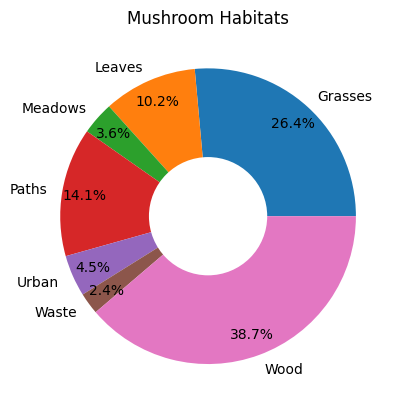

In [18]:
labels = ["Grasses", "Leaves", "Meadows", "Paths", "Urban", "Waste", "Wood"]

plt.pie(habitat["class"], labels=labels, autopct="%1.1f%%", pctdistance=0.85)
center_circle = plt.Circle((0, 0), 0.4, fc="white")
fig = plt.gcf()
fig.gca().add_artist(center_circle)
plt.title("Mushroom Habitats")

plt.show()

### Waffles

A way to visualize quantities as a `2D array of squares`.

Select a segment of our data to group by e.g.the cap color:

In [22]:
capcolor = mushrooms.groupby(["cap-color"]).count()
capcolor

,class,cap-shape,cap-surface,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
cap-color,,,,,,,,,,,,,,,,,,,,,
Brown,2284,2284,2284,2284,1100,2284,2284,2284,2284,2284,...,2284,2284,2284,2284,2284,2272,2272,2284,2284,2284
Buff,168,168,168,168,96,168,168,168,168,168,...,168,168,168,168,168,168,168,168,168,168
Cinnamon,44,44,44,44,12,44,44,44,44,44,...,44,44,44,44,44,32,32,44,44,44
Green,1856,1856,1856,1856,808,1856,1856,1856,1856,1856,...,1856,1856,1856,1856,1856,1856,1856,1856,1856,1856
Pink,144,144,144,144,64,144,144,144,144,144,...,144,144,144,144,144,144,144,144,144,144
Purple,16,16,16,16,0,16,16,16,16,16,...,16,16,16,16,16,16,16,16,16,16
Red,1500,1500,1500,1500,876,1500,1500,1500,1500,1500,...,1500,1500,1500,1500,1500,1488,1488,1500,1500,1500
White,1040,1040,1040,1040,592,1040,1040,1040,1040,1040,...,1040,1040,1040,1040,1040,1040,1040,1040,1040,1040
Yellow,1072,1072,1072,1072,1048,1072,1072,1072,1072,1072,...,1072,1072,1072,1072,1072,1072,1072,1072,1072,1072


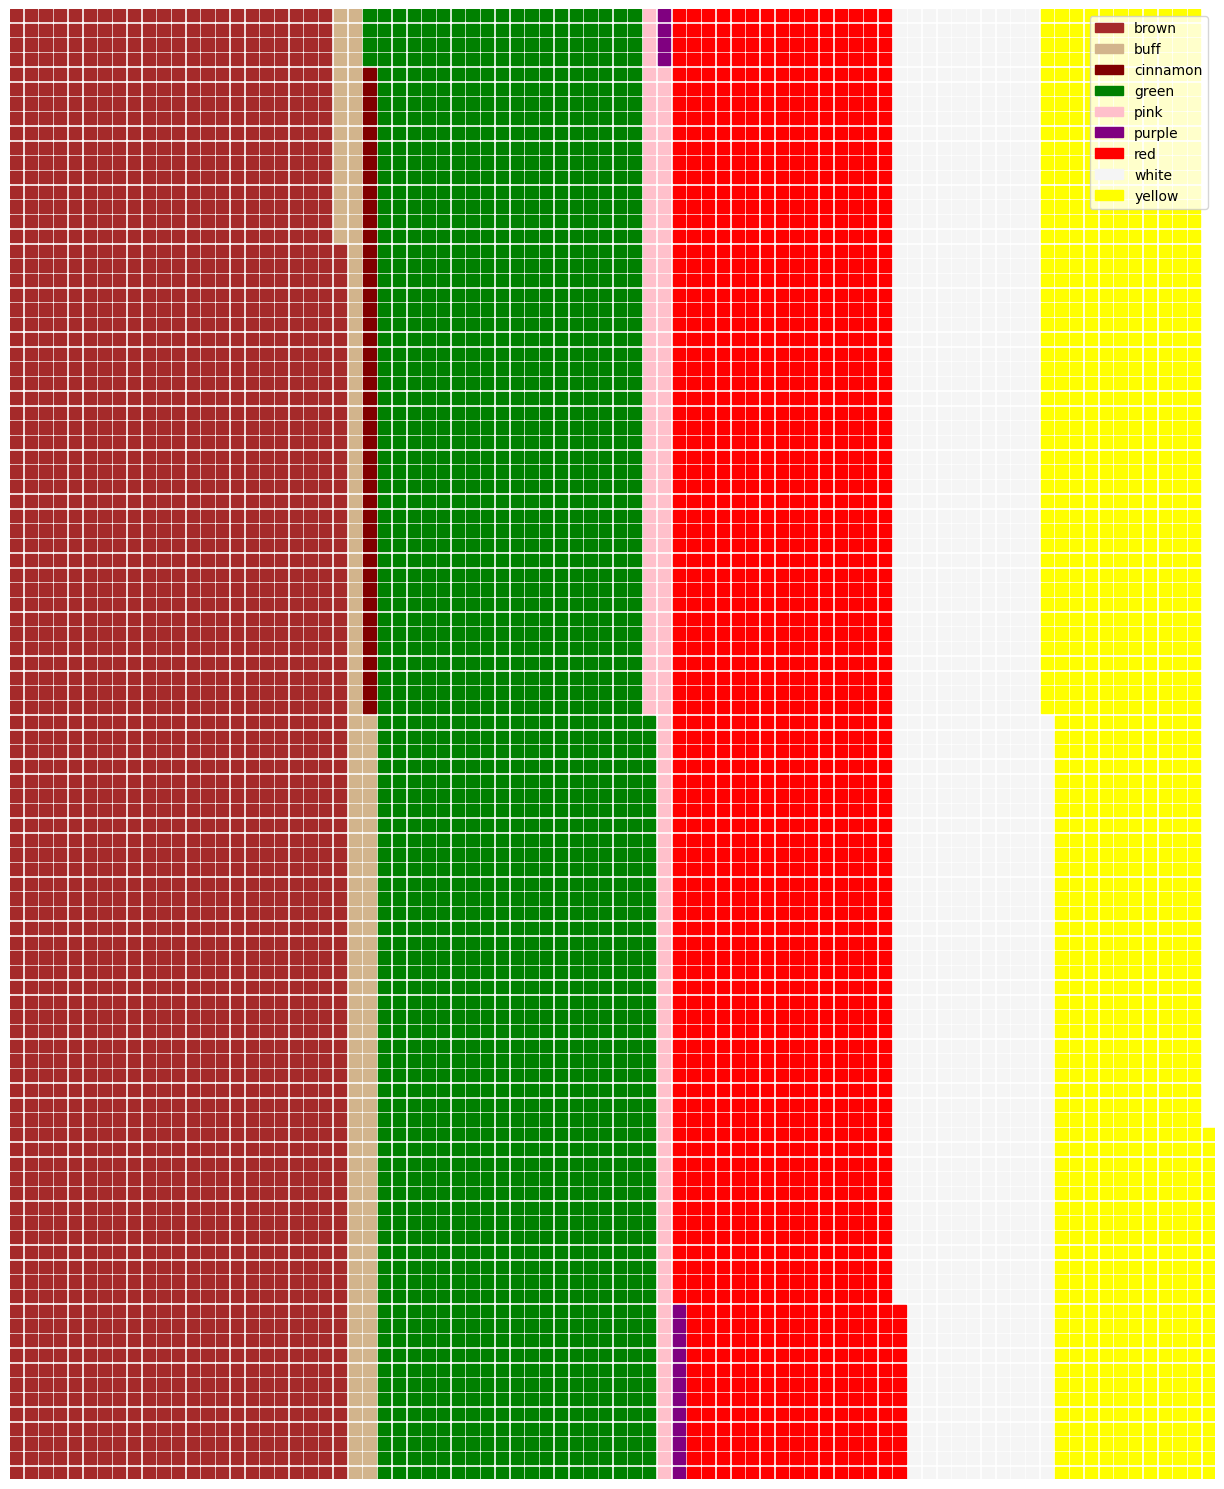

In [29]:
from pywaffle import Waffle

data = {
    "color": ["brown", "buff", "cinnamon", "green", "pink", "purple", "red", "white", "yellow"],
    "amount": capcolor["class"],
}

df = pd.DataFrame(data)

fig = plt.figure(
    FigureClass=Waffle,
    rows=100,
    values=df.amount,
    labels=list(df.color),
    figsize=(15, 15),
    colors=["brown", "tan", "maroon", "green", "pink", "purple", "red", "whitesmoke", "yellow"],
)